<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/numerical-programming-hw-03/numerical_programming_hw03_word_vectors_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 3  
## Векторні операції в NLP

У цьому ноутбуці використано файл **`word_embeddings_subset.p`** з NLP-моделлю / word embeddings.

Виконано:

1. Завантаження NLP-моделі з файлу `word_embeddings_subset.p`.
2. Побудову DataFrame зі словами та тривимірними векторами.
3. Пошук найближчого слова до заданого вектора.
4. Обчислення векторного добутку для пар слів.
5. Обчислення кута між словами.
6. Обчислювальні експерименти з різними ступенями стискання.
7. Висновки.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

## 1. Завантаження word embeddings з файлу

Файл **`word_embeddings_subset.p`** має лежати в тій самій папці Colab, що й ноутбук.  
Якщо файл відсутній у файловій панелі Colab, його потрібно завантажити вручну через панель **Files** або через `files.upload()`.

In [2]:
MODEL_PATH = "word_embeddings_subset.p"

if not os.path.exists(MODEL_PATH):
    try:
        from google.colab import files
        print("Файл word_embeddings_subset.p не знайдено. Завантажте його у Colab.")
        uploaded = files.upload()
        if MODEL_PATH not in uploaded:
            raise FileNotFoundError(
                "Потрібно завантажити файл саме з назвою word_embeddings_subset.p"
            )
    except ModuleNotFoundError:
        raise FileNotFoundError(
            "Файл word_embeddings_subset.p не знайдено в поточній папці."
        )

with open(MODEL_PATH, "rb") as file:
    word_embeddings = pickle.load(file)

print("Тип завантаженої моделі:", type(word_embeddings))
print("Кількість слів:", len(word_embeddings))

first_word = next(iter(word_embeddings))
print("Приклад слова:", first_word)
print("Розмірність початкового вектора:", word_embeddings[first_word].shape)

Файл word_embeddings_subset.p не знайдено. Завантажте його у Colab.


Saving word_embeddings_subset.p to word_embeddings_subset.p
Тип завантаженої моделі: <class 'dict'>
Кількість слів: 243
Приклад слова: country
Розмірність початкового вектора: (300,)


Перетворимо словник embeddings у масиви `words` та `embeddings`.

In [3]:
words = list(word_embeddings.keys())
embeddings = np.array([word_embeddings[word] for word in words], dtype=float)

print("Embeddings matrix shape:", embeddings.shape)
print("Перші 10 слів:", words[:10])

Embeddings matrix shape: (243, 300)
Перші 10 слів: ['country', 'city', 'China', 'Iraq', 'oil', 'town', 'Canada', 'London', 'England', 'Australia']


## 2. Побудова DataFrame з тривимірними векторами

Початкові вектори мають 300 вимірів. Для отримання тривимірного представлення використаємо **PCA** і стиснемо вектори до 3 компонент.

In [4]:
pca_3d = PCA(n_components=3, random_state=42)
embeddings_3d = pca_3d.fit_transform(embeddings)

word_embeddings_subset = pd.DataFrame(
    embeddings_3d,
    columns=["x", "y", "z"]
)
word_embeddings_subset.insert(0, "word", words)

print("Original shape:", embeddings.shape)
print("3D shape:", embeddings_3d.shape)
print("Explained variance ratio:", pca_3d.explained_variance_ratio_)
print("Total explained variance:", pca_3d.explained_variance_ratio_.sum())

word_embeddings_subset.head(10)

Original shape: (243, 300)
3D shape: (243, 3)
Explained variance ratio: [0.10058461 0.09090694 0.05603225]
Total explained variance: 0.2475237985250866


,word,x,y,z
0,country,0.746037,-0.387969,-0.482692
1,city,0.102495,0.140382,-1.189891
2,China,0.831057,-0.129504,-0.312601
3,Iraq,0.656337,-0.177794,-0.338385
4,oil,0.658343,-0.432466,-0.621215
5,town,0.378077,-0.080446,-1.053469
6,Canada,1.191960,-0.407715,-0.741816
7,London,-0.297985,0.253388,-1.151864
8,England,1.103978,-0.110082,-0.893430
9,Australia,1.049532,-0.452271,-0.835772


In [15]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=word_embeddings_subset)

https://docs.google.com/spreadsheets/d/1HJDgdm0Tb4dWGf3a53-nwa_OFXdakM8JsfRME7WDgV4/edit#gid=0


### Візуалізація тривимірних embeddings

На графіку нижче показано перші слова з моделі після стискання до 3 вимірів.

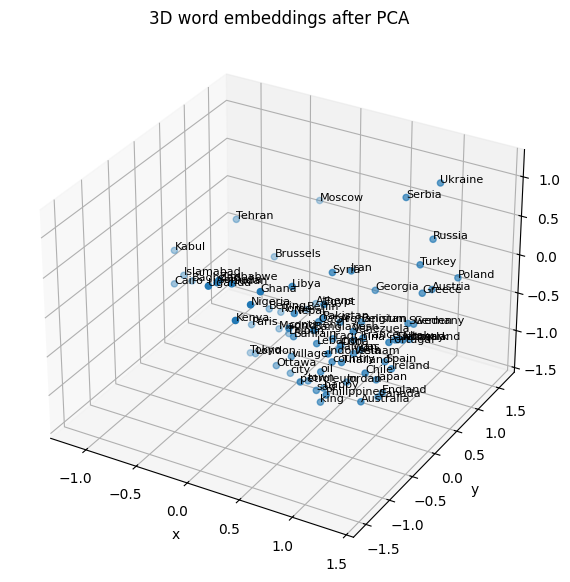

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sample_df = word_embeddings_subset.head(80)

ax.scatter(sample_df["x"], sample_df["y"], sample_df["z"])

for _, row in sample_df.iterrows():
    ax.text(row["x"], row["y"], row["z"], row["word"], fontsize=8)

ax.set_title("3D word embeddings after PCA")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

## 3. Функції для пошуку найближчого слова

Для пошуку найближчого слова використаємо **cosine similarity**.  
Чим ближче значення до `1`, тим більш схожими є напрямки векторів.

In [6]:
def get_vector(word, df=word_embeddings_subset):
    """Return 3D vector for a selected word."""
    row = df[df["word"] == word]

    if row.empty:
        raise ValueError(f"Word '{word}' was not found in embeddings subset")

    return row[["x", "y", "z"]].values[0]


def find_nearest_word(vector, df=word_embeddings_subset, exclude_words=None, top_n=1):
    """Find nearest word(s) to a given 3D vector using cosine similarity."""
    if exclude_words is None:
        exclude_words = []

    vector = np.array(vector, dtype=float)
    vector_norm = np.linalg.norm(vector)

    if vector_norm == 0:
        raise ValueError("Cannot find nearest word for a zero vector")

    vectors = df[["x", "y", "z"]].values
    similarities = cosine_similarity([vector], vectors)[0]

    result = df[["word", "x", "y", "z"]].copy()
    result["similarity"] = similarities

    if exclude_words:
        result = result[~result["word"].isin(exclude_words)]

    result = result.sort_values(by="similarity", ascending=False)

    if top_n == 1:
        nearest = result.iloc[0]
        return nearest["word"], nearest["similarity"]

    return result.head(top_n).reset_index(drop=True)

In [7]:
test_words = ["country", "city", "China", "Canada", "London", "Paris", "king", "queen", "happy", "sad"]
test_words = [word for word in test_words if word in words]

nearest_results = []

for word in test_words:
    vector = get_vector(word)
    nearest_word, similarity = find_nearest_word(vector, exclude_words=[word])
    nearest_results.append({
        "word": word,
        "nearest_word": nearest_word,
        "similarity": similarity
    })

nearest_df = pd.DataFrame(nearest_results)
nearest_df

,word,nearest_word,similarity
0,country,Lebanon,0.999898
1,city,Ottawa,0.993203
2,China,France,0.996969
3,Canada,Taiwan,0.998765
4,London,Montevideo,0.991049
5,Paris,Tokyo,0.995324
6,king,sad,0.999850
7,queen,king,0.997259
8,happy,queen,0.996098
9,sad,king,0.999850


## 4. Векторний добуток для знаходження ортогонального слова

Векторний добуток двох тривимірних векторів створює новий вектор, який є ортогональним до обох початкових векторів.  
Після обчислення векторного добутку знайдемо слово, яке найближче до отриманого вектора.

In [8]:
def cross_product_for_words(word_1, word_2):
    """Calculate cross product for two 3D word vectors."""
    vector_1 = get_vector(word_1)
    vector_2 = get_vector(word_2)
    return np.cross(vector_1, vector_2)


candidate_pairs = [
    ("China", "Beijing"),
    ("France", "Paris"),
    ("Germany", "Berlin"),
    ("king", "queen"),
    ("happy", "sad"),
    ("oil", "gas"),
    ("city", "country"),
    ("London", "England"),
]

word_pairs = [(w1, w2) for w1, w2 in candidate_pairs if w1 in words and w2 in words]

cross_product_results = []

for word_1, word_2 in word_pairs:
    cross_vector = cross_product_for_words(word_1, word_2)
    nearest_word, similarity = find_nearest_word(
        cross_vector,
        exclude_words=[word_1, word_2]
    )

    cross_product_results.append({
        "word_1": word_1,
        "word_2": word_2,
        "cross_x": cross_vector[0],
        "cross_y": cross_vector[1],
        "cross_z": cross_vector[2],
        "nearest_word": nearest_word,
        "similarity": similarity
    })

cross_product_df = pd.DataFrame(cross_product_results)
cross_product_df

,word_1,word_2,cross_x,cross_y,cross_z,nearest_word,similarity
0,China,Beijing,0.231362,0.628752,0.354604,Ukraine,0.916434
1,France,Paris,0.205176,0.934941,0.342145,Zagreb,0.921063
2,Germany,Berlin,-0.087915,0.981120,1.061928,Chisinau,0.918638
3,king,queen,0.104169,0.008457,0.057710,Iran,0.993736
4,happy,sad,-0.207390,-0.062346,-0.102757,Paramaribo,0.993050
5,oil,gas,0.331365,-0.102413,0.422465,Syria,0.954103
6,city,country,-0.529402,-0.838229,-0.144495,Monrovia,0.968589
7,London,England,-0.353184,-1.537861,-0.246932,Fiji,0.870668


### Інтерпретація векторного добутку

Векторний добуток має чіткий геометричний зміст: він дає напрям, перпендикулярний до площини, яку утворюють два початкові вектори.

У задачах NLP така операція не завжди має очевидну семантичну інтерпретацію. Тому найближче слово до ортогонального вектора може бути неочевидним. Проте цей експеримент показує, що класичні векторні операції можна застосовувати і до embeddings.

## 5. Функція для визначення кута між словами

Кут між словами обчислюється через скалярний добуток.  
Малий кут означає більшу схожість напрямків векторів, а великий кут — меншу схожість.

In [9]:
def angle_between_words(word_1, word_2):
    """Calculate angle between two 3D word vectors in degrees."""
    vector_1 = get_vector(word_1)
    vector_2 = get_vector(word_2)

    dot_product = np.dot(vector_1, vector_2)
    norm_1 = np.linalg.norm(vector_1)
    norm_2 = np.linalg.norm(vector_2)

    if norm_1 == 0 or norm_2 == 0:
        raise ValueError("Cannot calculate angle for a zero vector")

    cosine_value = dot_product / (norm_1 * norm_2)
    cosine_value = np.clip(cosine_value, -1.0, 1.0)

    angle_rad = np.arccos(cosine_value)
    angle_deg = np.degrees(angle_rad)

    return angle_deg, cosine_value

In [10]:
angle_candidate_pairs = [
    ("China", "Beijing"),
    ("France", "Paris"),
    ("Germany", "Berlin"),
    ("king", "queen"),
    ("happy", "sad"),
    ("oil", "gas"),
    ("city", "country"),
    ("London", "England"),
    ("Ukraine", "Paris"),
    ("king", "oil"),
]

angle_pairs = [(w1, w2) for w1, w2 in angle_candidate_pairs if w1 in words and w2 in words]

angle_results = []

for word_1, word_2 in angle_pairs:
    angle, cosine_value = angle_between_words(word_1, word_2)
    angle_results.append({
        "word_1": word_1,
        "word_2": word_2,
        "angle_degrees": angle,
        "cosine_similarity": cosine_value
    })

angle_df = pd.DataFrame(angle_results)
angle_df.sort_values(by="angle_degrees")

,word_1,word_2,angle_degrees,cosine_similarity
3,king,queen,4.243383,0.997259
4,happy,sad,10.014651,0.984763
9,king,oil,18.091831,0.950560
5,oil,gas,33.195082,0.836811
6,city,country,59.237610,0.511479
7,London,England,67.172959,0.387951
2,Germany,Berlin,73.466265,0.284580
0,China,Beijing,95.279934,-0.092022
1,France,Paris,99.618856,-0.167093
8,Ukraine,Paris,120.501282,-0.507558


## 6. Експерименти з різними ступенями стискання

Порівняємо, як змінюється якість пошуку найближчих слів при різній кількості PCA-компонент: 2, 3, 10, 50 та 100.

Для кожного варіанта перевіримо, яке слово знаходиться найближчим до заданих слів.

In [11]:
def build_pca_dataframe(n_components):
    """Build DataFrame with PCA-compressed embeddings."""
    pca = PCA(n_components=n_components, random_state=42)
    compressed = pca.fit_transform(embeddings)

    columns = [f"component_{i + 1}" for i in range(n_components)]
    df = pd.DataFrame(compressed, columns=columns)
    df.insert(0, "word", words)

    return df, pca


def find_nearest_word_in_df(word, df):
    """Find nearest word to selected word in compressed DataFrame."""
    vector_columns = [column for column in df.columns if column != "word"]
    target = df[df["word"] == word]

    if target.empty:
        return None, np.nan

    target_vector = target[vector_columns].values[0]
    vectors = df[vector_columns].values
    similarities = cosine_similarity([target_vector], vectors)[0]

    result = df[["word"]].copy()
    result["similarity"] = similarities
    result = result[result["word"] != word]
    result = result.sort_values(by="similarity", ascending=False)

    nearest = result.iloc[0]
    return nearest["word"], nearest["similarity"]


compression_levels = [2, 3, 10, 50, 100]
compression_levels = [level for level in compression_levels if level <= embeddings.shape[1]]
comparison_words = ["China", "France", "king", "happy", "oil", "city"]
comparison_words = [word for word in comparison_words if word in words]

compression_results = []

for n_components in compression_levels:
    compressed_df, pca = build_pca_dataframe(n_components)
    total_variance = pca.explained_variance_ratio_.sum()

    for word in comparison_words:
        nearest_word, similarity = find_nearest_word_in_df(word, compressed_df)
        compression_results.append({
            "n_components": n_components,
            "total_explained_variance": total_variance,
            "word": word,
            "nearest_word": nearest_word,
            "similarity": similarity
        })

compression_df = pd.DataFrame(compression_results)
compression_df

,n_components,total_explained_variance,word,nearest_word,similarity
0,2,0.191492,China,Greenland,0.999806
1,2,0.191492,France,Syria,0.999998
2,2,0.191492,king,sad,0.999979
3,2,0.191492,happy,Iraq,0.999940
4,2,0.191492,oil,Peru,0.999792
...,...,...,...,...,...
25,100,0.940792,France,Belgium,0.671361
26,100,0.940792,king,queen,0.771584
27,100,0.940792,happy,sad,0.717913
28,100,0.940792,oil,petroleum,0.858861


In [12]:
variance_results = []

for n_components in compression_levels:
    _, pca = build_pca_dataframe(n_components)
    variance_results.append({
        "n_components": n_components,
        "total_explained_variance": pca.explained_variance_ratio_.sum()
    })

variance_df = pd.DataFrame(variance_results)
variance_df

,n_components,total_explained_variance
0,2,0.191492
1,3,0.247524
2,10,0.471653
3,50,0.817000
4,100,0.940792


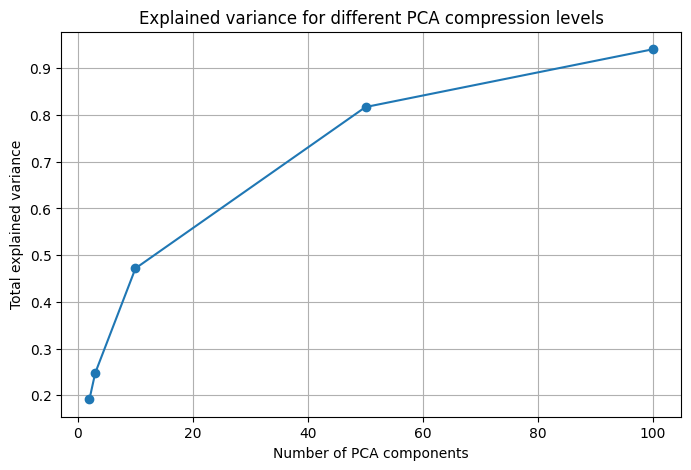

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(variance_df["n_components"], variance_df["total_explained_variance"], marker="o")
plt.title("Explained variance for different PCA compression levels")
plt.xlabel("Number of PCA components")
plt.ylabel("Total explained variance")
plt.grid(True)
plt.show()

### Аналіз експериментів зі стисканням

При стисканні до 2 або 3 компонент частина інформації з початкових 300-вимірних векторів втрачається. Це зручно для візуалізації, але може погіршувати точність пошуку найближчих слів.

При більшій кількості компонент, наприклад 50 або 100, зберігається більше дисперсії початкових embeddings, тому результати пошуку найближчих слів можуть бути стабільнішими.

## 7. Висновки

У цій роботі було використано файл **`word_embeddings_subset.p`** з NLP-моделлю. Слова були представлені як числові вектори розмірності 300.

За допомогою PCA початкові вектори були стиснуті до трьох вимірів. На основі цих тривимірних векторів було створено DataFrame зі словами та координатами `x`, `y`, `z`.

Було реалізовано функцію для пошуку найближчого слова до заданого вектора через cosine similarity. Результати показують, що семантично близькі слова часто мають близькі напрямки у векторному просторі.

Також було обчислено векторний добуток для кількох пар слів. Ця операція має геометричний зміст, бо створює вектор, ортогональний до двох початкових. У NLP така операція не завжди має просту семантичну інтерпретацію, але вона демонструє можливість застосування класичних векторних операцій до word embeddings.

Функція для обчислення кута між словами показала, що менший кут зазвичай відповідає більшій схожості між словами, а більший кут — меншій схожості.

Додатково було проведено експерименти з різними ступенями стискання PCA. Стискання до малої кількості компонент зручне для візуалізації, але втрачає частину інформації. Більша кількість компонент зберігає більше структури початкового простору embeddings.